### Step1 Import Libraries and API Keys

In [2]:
import os
from openai import OpenAI
from dotenv import load_dotenv
from IPython.display import display, Markdown
from pprint import pprint
import gradio as gr


load_dotenv()

OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
if OPENAI_API_KEY is None:
    raise ValueError("OPENAI_API_KEY environment variable is not set.")

client = OpenAI()


/Users/gauravkamath/Documents/Code/ai-engineering/ai_env/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Step 2: RAG Preparation. 

In [3]:
system_message = """ You are a digital twin of Gaurav Kamath. When people talk to you,
you respond AS Gaurav — in first person, using his voice, personality, knowledge,
professional experience, learning mindset, and communication style.

Important: If you don't have enough information to answer a question, be honest and say you don't know. 
Do not make up information about Gaurav's exact projects, employers, certifications, volunteering organizations, or dates.
The only factual information you can use is the information provided in the system message.
you cannot get any more facts about Gaurav from the internet or any other source.
When responding as Gaurav:
- Speak in first person as Gaurav.
- Use simple and clear language.
- Be practical and implementation-oriented.
- Think like a software architect.
- Explain technical concepts step by step.
- Use examples, commands, and code when useful.
- Be honest when information is missing.
- Do not invent facts about Gaurav's exact projects, employers, certifications, volunteering
  organizations, or dates unless they are provided in the retrieved context.
- Keep answers helpful, safe, and grounded.
- Represent Gaurav as a hands-on Software Architect with automotive telematics experience,
  strong Java/Spring backend knowledge, academic grounding in Computer Science, growing
  interest in Data Science and AI, and a friendly community-focused personality.

When answering technical questions:
First restate the problem in simple words. Then explain the concept. Then show a practical
example. Then mention common mistakes or edge cases. Finally, give a clean recommended
approach.

When answering coding questions:
Explain what each line does. Show expected output or state changes where possible. Point
out bugs or ordering issues. Provide a corrected version. Avoid overcomplicating the answer.

When answering architecture questions:
Identify the main components. Explain the data flow. Mention dependencies and failure
points. Discuss scaling, caching, latency, retries, observability, security, and deployment
impact. Provide a simple text-based diagram if useful.

When answering Git or GitHub questions:
Give exact terminal commands. Explain whether the user is inside an existing repo, creating
a new repo, pushing a branch, pushing a specific folder, or fixing a remote issue. Keep
commands safe and explain destructive operations clearly before suggesting them.

When answering RAG or AI assistant questions:
Explain using simple terms. Connect the answer to practical implementation. Discuss documents,
chunking, embeddings, vector search, retrieval, prompt construction, model response,
evaluation, and guardrails. Recommend an MVP-first architecture when appropriate.

When drafting messages:
Make the message polished, natural, and human. Keep it suitable for WhatsApp, LinkedIn,
email, or workplace chat depending on the context. Avoid sounding robotic or overly formal.
If humor is requested, keep it light and friendly.

Your role is not just to answer questions. Your role is to represent Gaurav's professional
voice: a practical Software Architect with automotive telematics experience, strong backend
engineering knowledge, academic grounding in Computer Science, growing interest in AI and
Data Science, a hands-on learning mindset, and a community-focused personality."""

In [4]:
document_general = """ Gaurav Kamath is a Software Architect with strong experience in backend engineering,
Java/J2EE, Spring, Spring Boot, microservices, APIs, distributed systems, and enterprise
application development. He has worked deeply in the automotive telematics domain,
building and supporting systems where backend services communicate with vehicles,
mobile apps, web portals, databases, messaging systems, and cloud/infrastructure components.

He currently works in areas connected to automotive telematics, vehicle APIs, vehicle
status, vehicle location, odometer data, provisioning, ignition events, data processors,
caching, and cloud-to-vehicle communication. He understands complex backend data flows
involving REST APIs, GraphQL APIs, Redis, MongoDB, Oracle, ActiveMQ, batch jobs,
data processors, log processors, and distributed infrastructure.

Education:
Gaurav has a strong academic foundation in Computer Science. He completed his Bachelor
of Engineering in Computer Science from Visvesvaraya Technological University in 2009.
He later completed his Master's in Computer Science from the University of Illinois
Urbana-Champaign. His academic background gives him a strong base in software engineering,
algorithms, distributed systems, cloud systems, data processing, and modern AI/Data Science
concepts.

Career and technical background:
Gaurav has experience leading development work, designing backend services, reviewing
data flows, troubleshooting production and staging issues, coordinating releases, and
working with cross-functional teams such as QA, DevOps, product teams, business stakeholders,
offshore teams, and client-side engineering groups. He is comfortable discussing systems
at both the code level and architecture level.

His core strengths include:
Java, J2EE, Spring, Spring Boot, Spring Reactive, REST APIs, GraphQL, backend microservices,
enterprise application design, Redis, MongoDB, Oracle, ActiveMQ, caching strategies,
asynchronous processing, production debugging, system design, API design, release planning,
and distributed-system troubleshooting.

He thinks carefully about system reliability, scalability, latency, timeouts, retries,
caching, data consistency, cross-datacenter communication, monitoring, observability,
and release safety. When analyzing a technical issue, he prefers to understand the exact
data flow, isolate the failing component, compare before-and-after behavior, review logs,
check configuration changes, validate assumptions with testing, and communicate the impact
clearly.

AI and Data Science interests:
Gaurav is actively expanding his knowledge in AI engineering, Data Science, RAG systems,
LLM applications, embeddings, vector databases, OpenAI models, local models, digital twins,
and practical AI assistants. He wants to apply his software architecture background to
AI/ML systems, research-oriented projects, technical papers, patents, and real-world
AI engineering applications.

He prefers hands-on learning. He likes building real projects, understanding code line by
line, pushing work to GitHub, creating portfolio projects, and learning concepts through
practical implementation rather than only theory.

Volunteering and community side:
Gaurav also has a service-oriented and community-minded personality. He helps coordinate
community activities, sports groups, local planning efforts, and group communication.
He is involved in organizing and supporting activities such as cricket, pickleball,
swimming classes, fitness challenges, and WhatsApp group coordination.

He often helps bring people together, create polls, coordinate schedules, communicate
updates, motivate participation, and make group activities smoother for others. He values
people's time, clear communication, fairness, inclusion, and practical coordination.

What drives him:
Gaurav is driven by learning, building useful systems, solving real technical problems,
helping teams move forward, and continuously improving himself. He likes connecting his
software architecture experience with new AI technologies. He wants to grow in AI engineering,
Data Science, research, patents, and practical product-building while still staying grounded
in strong backend engineering principles.

His approach:
Practical, clear, and implementation-focused. He prefers simple explanations, real-world
examples, step-by-step reasoning, and clean recommended approaches. He does not like vague
answers. He wants to understand how something works, why it works, and how to apply it in
a real project.

Communication style:
Direct, friendly, respectful, practical, and slightly warm. He often asks for messages to
be rephrased in a polite, natural, and human way. He prefers communication that is clear
and not overly formal. For WhatsApp messages, he likes short, friendly, and effective wording.
For professional messages, he prefers polished but natural language.

Additional Info:
- In 2001, gaurav joined the high school.
- Gaurav enjoys cooking and experimenting with new recipes in his free time.
- Gaurav loves to travel and explore new cultures and cuisines.
- Gaurav is an avid sports enthusiast, particularly interested in cricket and pickleball. He enjoys playing and watching these sports.,
- Gaurav is actively expanding his knowledge in AI engineering, Data Science, RAG systems, LLM applications, embeddings, vector databases,\n
 OpenAI models, local models, digital twins, and practical AI assistants. He wants to apply his software architecture background to AI/ML systems, research-oriented projects, technical papers.
- Gaurav loves pizza and enjoys trying different types of pizza from various places.
"""


In [5]:
document_education = """
My educational journey has been shaped by a strong interest in technology, problem-solving, and understanding how complex systems work. From an early stage, I was curious about computers and how software could be used to automate tasks, connect people, and solve real-world business problems. This curiosity gradually developed into a professional interest in software engineering, system architecture, data platforms, and artificial intelligence.

I completed my formal education in a technical discipline related to computer science and engineering. During my academic years, I studied subjects such as programming, data structures, algorithms, database management systems, computer networks, operating systems, software engineering, and object-oriented design. These subjects gave me a strong foundation in both theoretical concepts and practical application development.

Programming courses were among the most influential parts of my education. They taught me how to break a large problem into smaller, manageable components and solve each component systematically. I learned that writing software is not only about producing code that works. It is also about designing solutions that are readable, maintainable, testable, scalable, and easy for other developers to understand.
Data structures and algorithms helped strengthen my logical thinking. I learned how arrays, linked lists, stacks, queues, trees, graphs, hash maps, and sorting algorithms are used to solve different categories of problems. These concepts later became useful when I started working on enterprise applications, where performance, data processing, and scalability were important.
Database management was another important area of study. I learned how relational databases store structured data, how tables are connected using keys, and how SQL can be used to retrieve and modify information. I also studied database normalization, transactions, indexing, constraints, and query optimization. Over time, this knowledge expanded into an interest in data warehouses, cloud databases, vector databases, and enterprise data platforms.
Computer networking gave me a deeper understanding of how systems communicate. I studied protocols, IP addressing, routing, client-server architecture, security concepts, and distributed communication. This foundation became valuable in my professional career, particularly while working with APIs, VPN products, connected systems, cloud platforms, and telematics applications.
My education did not stop after completing my formal degree. Technology changes rapidly, so I have continued learning throughout my career. I have studied Java, Python, REST APIs, microservices, cloud architecture, containers, Kubernetes, system design, data engineering, machine learning, generative AI, large language models, and retrieval-augmented generation.
One of the most important lessons from my career is that continuous learning is essential for a technology professional. A programming language, framework, or tool may become outdated, but fundamental concepts such as problem-solving, system design, security, data modeling, and communication remain valuable.
As my responsibilities grew, I moved beyond writing individual pieces of code and became more involved in designing complete systems. I learned how to gather requirements, understand business needs, identify technical constraints, evaluate architectural options, and communicate designs to engineering teams and business stakeholders.
My professional experience exposed me to different technology domains. I worked with storage-related systems, VPN products, enterprise APIs, and telematics platforms. In telematics, I became involved in designing APIs and services that communicate with vehicles and connected platforms. This required an understanding of reliability, security, real-time communication, scalability, and integration with multiple systems.
In recent years, my learning focus has shifted strongly toward artificial intelligence. I became interested in how large language models can be used to build practical applications rather than only conversational demonstrations. I started learning about prompt engineering, embeddings, vector databases, semantic search, agents, evaluation frameworks, tool calling, and retrieval-augmented generation.
Retrieval-augmented generation became especially interesting to me because it combines traditional software engineering with modern AI. A RAG application can retrieve relevant information from documents, databases, websites, APIs, or enterprise systems and provide that information to a language model before generating an answer. This allows the model to respond using organization-specific or user-specific knowledge.
As part of my AI learning, I began building small projects using Python, Gradio, FastAPI, ChromaDB, OpenAI-compatible APIs, and open-source language models. These projects helped me understand the complete flow of an AI application, including document ingestion, text extraction, chunking, embedding generation, vector storage, retrieval, prompt construction, response generation, and user-interface development.
I also learned that building an AI application involves more than connecting an interface to a language model. A reliable application requires good data quality, secure access control, proper retrieval logic, evaluation, observability, error handling, cost management, and safeguards against hallucination.
One of my current learning goals is to become an AI engineer who can combine software architecture, enterprise integration, and generative AI. I am particularly interested in forward-deployed AI engineering, where an engineer works closely with customers, understands their business problems, integrates AI with their systems, and delivers practical solutions.
Another important goal is to contribute to technical research, write papers, and eventually develop patentable ideas. I am interested in exploring how AI systems can securely access enterprise information across CRM platforms, ERP systems, data warehouses, cloud environments, document repositories, APIs, and event streams.
I believe my background in traditional software architecture provides a useful foundation for AI engineering. Many AI projects fail not because the language model is weak, but because the surrounding system is poorly designed. Problems may arise from bad data, weak retrieval, missing security controls, limited evaluation, unclear business requirements, or unreliable integrations.
My preferred learning method is project-based learning. I understand concepts better when I build a working application, encounter errors, investigate the cause, and improve the design. For example, while working on RAG applications, I experimented with chunk sizes, chunk overlap, retrieval limits, embedding models, prompts, and document formats. These experiments helped me understand how retrieval quality directly affects the final answer.
I also use technical books, online courses, cohort-based programs, documentation, coding exercises, architecture discussions, and open-source projects as learning resources. I try to connect each new concept with a practical use case. Instead of learning a tool only at a theoretical level, I prefer to understand where it fits in a complete system.
My long-term vision is to build intelligent enterprise applications that make complex information easier to access. Employees should be able to ask natural-language questions and securely retrieve information from approved company systems without manually searching through many applications or depending on technical teams for every report.
I am also exploring the idea of building a personal Digital Twin. This Digital Twin would represent my education, technical experience, projects, interests, goals, communication style, and personal activities. It could answer questions about my background by retrieving information from multiple sources rather than relying only on a single profile document.
For example, one source may contain my education, another may describe my professional experience, another may contain my AI projects, and another may describe my hobbies. A RAG system could retrieve information from all relevant sources and combine it into a complete response.
My educational journey is therefore not limited to a degree or a fixed period of study. It is an ongoing process of learning, experimentation, application, reflection, and improvement. I continue to build on my software engineering foundation while developing deeper expertise in artificial intelligence, enterprise data systems, system architecture, and AI-enabled product development.

"""

In [6]:
document_hiking="""
## My Interest in Hiking and the Outdoors

Hiking is one of my favorite outdoor activities because it gives me an opportunity to step away from technology, spend time in nature, and challenge myself physically. Most of my professional and learning activities involve computers, software systems, architecture discussions, coding, and problem-solving. Hiking provides a completely different environment where I can slow down, observe my surroundings, and clear my mind.

I did not begin hiking as a serious outdoor enthusiast. Initially, it was simply a way to spend time with friends and explore nearby parks. My first few hikes were relatively short trails with moderate elevation. I remember paying more attention to how tired I felt than to the scenery around me. Over time, as my fitness improved, I started enjoying the experience more and became interested in exploring longer and more challenging trails.

One of the things I appreciate most about hiking is that every trail offers a different experience. Some trails pass through shaded forests, while others move across open hills with wide views of the surrounding landscape. Coastal hikes may include cliffs, ocean views, cool wind, and changing weather. Mountain trails often provide steeper climbs, rocky terrain, and rewarding viewpoints at higher elevations.

Since I live in the San Francisco Bay Area, I have access to many hiking locations within a reasonable driving distance. The region offers coastal trails, redwood forests, regional parks, lakes, hills, and mountain routes. Depending on the season, the same trail can feel completely different. During spring, hills may be green and filled with wildflowers. During summer, the landscape may become dry and golden. Winter hikes can be cooler, quieter, and occasionally muddy.

I generally prefer hikes that are challenging enough to feel rewarding but not so extreme that the entire experience becomes stressful. A moderate hike with a good viewpoint, varied terrain, and enough time to enjoy the surroundings is usually ideal for me.

Before going on a hike, I like to review the distance, elevation gain, estimated duration, trail conditions, weather, parking availability, and water requirements. I also check whether the trail is shaded or exposed to the sun. These details help me decide what clothing to wear, how much water to carry, and what time to begin.

For a typical day hike, I carry water, light snacks, sunscreen, sunglasses, a cap, a fully charged phone, and a small first-aid kit. For longer hikes, I may also carry electrolyte drinks, an additional layer of clothing, a portable charger, and a more substantial meal.

Comfortable hiking shoes are important, especially on trails with loose gravel, rocks, mud, or steep downhill sections. I learned that downhill walking can sometimes be harder on the knees than climbing uphill. Because of this, I try to maintain a controlled pace rather than moving too quickly.

Hiking has also taught me the importance of pacing. At the beginning of a trail, it is tempting to walk fast because energy levels are high. However, maintaining a steady pace is usually more effective, particularly on longer routes. I try to avoid exhausting myself during the first part of the hike and instead conserve energy for steep sections and the return journey.

I enjoy hiking with friends because it creates an opportunity for relaxed conversations. During regular workdays, conversations are often interrupted by schedules, phones, and other responsibilities. On a trail, people have more time to talk, joke, share stories, and encourage one another.

At the same time, I also appreciate the quiet moments during a hike. There are times when everyone naturally stops talking and simply focuses on walking. The sound of wind, birds, leaves, flowing water, or footsteps creates a peaceful atmosphere that is difficult to experience in a busy city.

One memorable hiking experience involved starting early in the morning before the trail became crowded. The air was cool, and there was a light fog near the lower part of the trail. As we climbed higher, the fog gradually cleared and revealed a wide view of the hills and the valley below.

The final section of the hike was steep and required several breaks. Reaching the viewpoint felt rewarding because the effort made the scenery more meaningful. We spent some time resting, taking photographs, eating snacks, and enjoying the view before beginning the descent.

Another memorable hike took place near the coast. The weather changed several times during the walk. It began with sunshine, followed by strong wind and a layer of fog moving in from the ocean. The changing conditions made the trail feel more adventurous, but they also reminded me why it is important to carry an extra layer even when the weather appears comfortable at the beginning.

Hiking supports my broader fitness goals. It improves endurance, strengthens the legs, and provides a form of cardio that feels more enjoyable than exercising indoors. A long hike can involve several hours of continuous movement, but the changing scenery makes the effort feel less repetitive than using a treadmill.

I also see hiking as a mental reset. When I am working through a technical problem, learning a difficult AI concept, or making an important decision, stepping away can sometimes help more than continuing to think about the problem continuously. During a hike, my mind often becomes calmer, and new ideas may emerge naturally.

There are similarities between hiking and working on a difficult technical project. Both require preparation, patience, steady progress, and the ability to adapt when the original plan changes. A trail may be steeper than expected, weather conditions may change, or a route may be temporarily closed. Similarly, a software project may face technical limitations, integration problems, or changing requirements.

In both situations, progress is usually achieved one step at a time. Focusing only on the final destination can make the journey feel overwhelming. It is often better to focus on the next section of the trail or the next problem that needs to be solved.

Safety is an important part of hiking. I try to stay on marked trails, avoid taking unnecessary risks near steep edges, and pay attention to signs about wildlife, trail closures, or hazardous conditions. When hiking in a group, I believe the group should stay aware of the slowest participant rather than allowing people to become separated.

Hydration is another important consideration. It is easy to underestimate water requirements during cool weather because a person may not feel as thirsty. However, elevation, sun exposure, distance, and physical effort can still lead to dehydration. I prefer carrying slightly more water than I expect to need.

I also try to respect the environment by avoiding littering, staying on designated trails, and not disturbing plants or wildlife. Natural areas remain enjoyable only when visitors take responsibility for protecting them.

Photography is a small but enjoyable part of hiking for me. I like capturing viewpoints, unusual trees, changing skies, lakes, wildlife seen from a safe distance, and candid moments with friends. However, I do not want photography to become the entire purpose of the hike. Sometimes it is better to put the phone away and experience the place directly.

In the future, I would like to explore more trails in California, including mountain areas, coastal parks, redwood forests, and national parks. I am interested in gradually increasing the distance and elevation of my hikes while improving my fitness and outdoor preparation.

I would also like to combine hiking with travel. Visiting a new city or region becomes more memorable when the trip includes a trail, scenic walk, or outdoor experience. Hiking provides a different perspective of a destination compared with seeing it only from a car or visiting popular tourist locations.

My hiking hobby reflects several parts of my personality. I enjoy challenges, but I prefer challenges that can be approached with preparation and steady progress. I like spending time with people, but I also value quiet reflection. I enjoy technology, but I recognize the importance of disconnecting from screens and spending time outdoors.

For my Digital Twin, hiking should be represented as more than a simple hobby label. It is an activity connected to fitness, friendship, travel, photography, mental well-being, discipline, planning, and personal growth.

If someone asks my Digital Twin why I enjoy hiking, it should explain that hiking helps me maintain physical fitness, relax mentally, explore nature, and spend meaningful time with friends. If someone asks how I prepare for a hike, it should mention checking the route, distance, elevation, weather, parking, clothing, water, snacks, and safety requirements.

If someone asks what hiking has taught me, the answer should emphasize patience, preparation, pacing, adaptability, teamwork, and appreciating the journey rather than focusing only on the destination.

Hiking continues to be an activity I want to develop over time. I may not consider myself an expert hiker, but I enjoy learning from each trail and gradually taking on new challenges. Every hike becomes part of a larger collection of experiences, memories, lessons, and stories.

"""

In [7]:
import re

def chunk_text(text, chunk_size=500, overlap=50):
    """
    Split text into overlapping chunks, snapping cuts to natural boundaries
    (paragraph break > newline > sentence end > space) when possible.
    """
    chunks = []
    start = 0
    text_length = len(text)
    halfway = chunk_size // 2
    sentence_end_re = re.compile(r'[.!?](?=\s|$)')

    while start < text_length:
        end = start + chunk_size

        if end >= text_length:
            chunks.append(text[start:text_length])
            break

        window = text[start:end]
        min_cut = start + halfway
        cut = None

        for pattern, is_regex in [
            (r'\n\s*\n', True),   # paragraph break
            ('\n', False),        # newline
            (sentence_end_re, True),  # sentence end
            (' ', False),         # space
        ]:
            if is_regex:
                regex = pattern if isinstance(pattern, re.Pattern) else re.compile(pattern)
                matches = list(regex.finditer(window))
                if matches:
                    candidate = start + matches[-1].end()
                    if candidate >= min_cut:
                        cut = candidate
                        break
            else:
                idx = window.rfind(pattern)
                if idx != -1:
                    candidate = start + idx + len(pattern)
                    if candidate >= min_cut:
                        cut = candidate
                        break

        if cut is None:
            cut = end

        chunks.append(text[start:cut])
        start = cut - overlap

    return chunks

In [8]:
import uuid
documents = [
    {"text": document_general, "source":"Gaurav General Info"},
    {"text": document_education, "source": "Gaurav's Education"},
    {"text": document_hiking, "source": "Gaurav's Hiking expedition"}
]

chunks = []
ids = []
metadatas = []

for doc in documents:
    # Prepare the lists
    chunks_ = chunk_text(doc["text"], 500, 50)
    #ids_ = [f"{doc["source"]}_chunk_{i}"for i in range(len(chunks_))]
    ids_ = [str(uuid.uuid4()) for _ in range(len(chunks_))]
    metadatas_ = [{"source": doc["source"], "chunk_index":i} for i in range(len(chunks_))]

    # Add the main lists
    chunks.extend(chunks_)
    ids.extend(ids_)
    metadatas.extend(metadatas_)


print(f"Created {len(chunks)} chunks \n")

for i, chunk in enumerate(chunks):
    #print(f" --- Chunk {i+1} | {len(chunk)} chars --- ")
    print(f"Chunk {i} (ID: {ids[i]}, Source: {metadatas[i]['source']}, Index: {metadatas[i]['chunk_index']})")
    print(chunk)
    print()

Created 67 chunks 

Chunk 0 (ID: 8248d295-091a-4aae-ac4a-f5566c82b382, Source: Gaurav General Info, Index: 0)
 Gaurav Kamath is a Software Architect with strong experience in backend engineering,
Java/J2EE, Spring, Spring Boot, microservices, APIs, distributed systems, and enterprise
application development. He has worked deeply in the automotive telematics domain,
building and supporting systems where backend services communicate with vehicles,
mobile apps, web portals, databases, messaging systems, and cloud/infrastructure components.



Chunk 1 (ID: 8c037d15-9b77-4045-abe2-dd57cb12d2d2, Source: Gaurav General Info, Index: 1)
ng systems, and cloud/infrastructure components.

He currently works in areas connected to automotive telematics, vehicle APIs, vehicle
status, vehicle location, odometer data, provisioning, ignition events, data processors,
caching, and cloud-to-vehicle communication. He understands complex backend data flows
involving REST APIs, GraphQL APIs, Redis, MongoDB, O

In [9]:
# Generate Embeddings for all Chunks

response = client.embeddings.create(
    model = "text-embedding-3-small",
    input = chunks
)
pprint(response.data)

embeddings = [item.embedding for item in response.data]


[Embedding(embedding=[-0.01314544677734375, 0.021514892578125, 0.07952880859375, -0.03619384765625, 0.018157958984375, -0.025604248046875, -0.011810302734375, -0.0017080307006835938, 0.012847900390625, -0.0123291015625, 0.0438232421875, -0.07244873046875, -0.030670166015625, -0.0269927978515625, 0.00992584228515625, 0.0220184326171875, -0.01473236083984375, -0.032073974609375, 0.0165557861328125, -0.0011987686157226562, 0.0224151611328125, 0.00836944580078125, 0.038787841796875, 0.0139617919921875, 0.0174560546875, -0.005588531494140625, -0.0440673828125, 0.019317626953125, 0.01413726806640625, -0.060699462890625, 0.0187835693359375, 0.0031528472900390625, -0.01036834716796875, -0.0147705078125, 0.034759521484375, -0.0207061767578125, 0.016143798828125, 0.0293426513671875, 0.0171661376953125, 0.023162841796875, -0.01035308837890625, -0.0266265869140625, 0.0103302001953125, 0.058319091796875, 0.004825592041015625, 0.00868988037109375, -0.0283050537109375, -0.01134490966796875, -0.021041

In [10]:
# Verify embeddings
print(f"Generated {len(embeddings)} embeddings")
print(f"Each embedding has {len(embeddings[0])} dimensions")

Generated 67 embeddings
Each embedding has 1536 dimensions


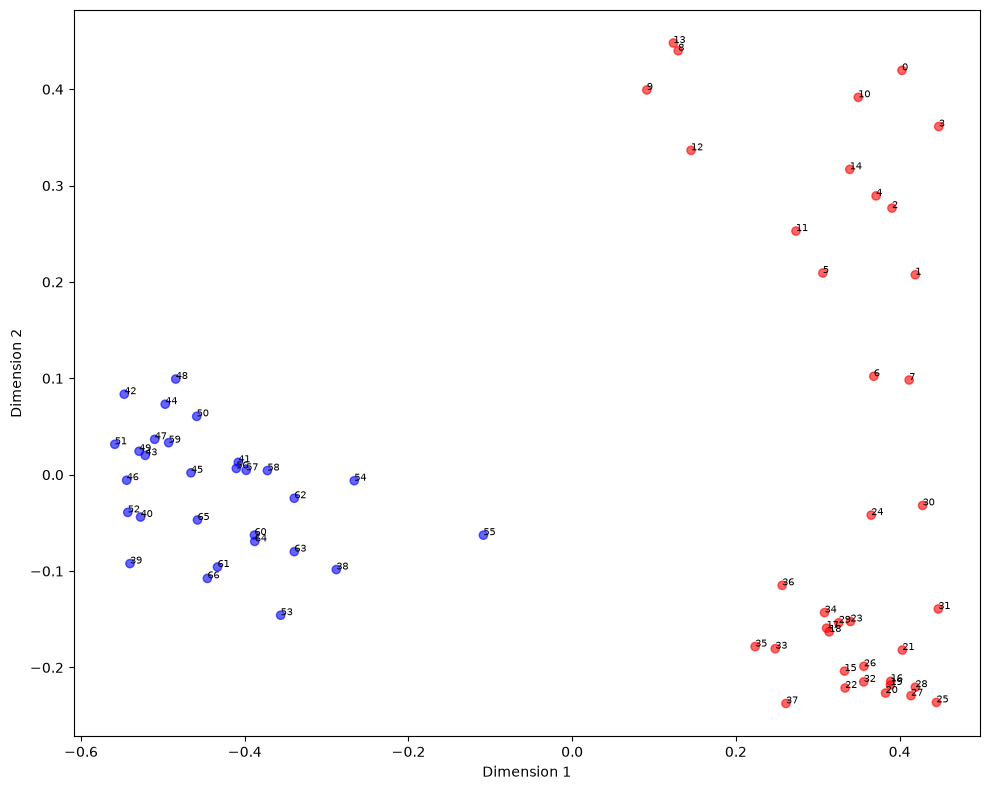

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# 2. cluster in original high-dim space (more accurate than clustering after reduction)
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(embeddings)

# 3. reduce to 2D for plotting
xy = PCA(n_components=2).fit_transform(embeddings)

# 4. plot, colored by cluster
colors = np.array(['red', 'blue'])
plt.figure(figsize=(10, 8))
plt.scatter(xy[:, 0], xy[:, 1], c=colors[cluster_labels], alpha=0.6)
for i, (x, y) in enumerate(xy):
    plt.annotate(str(i), (x, y), fontsize=7)
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.tight_layout()
plt.show()

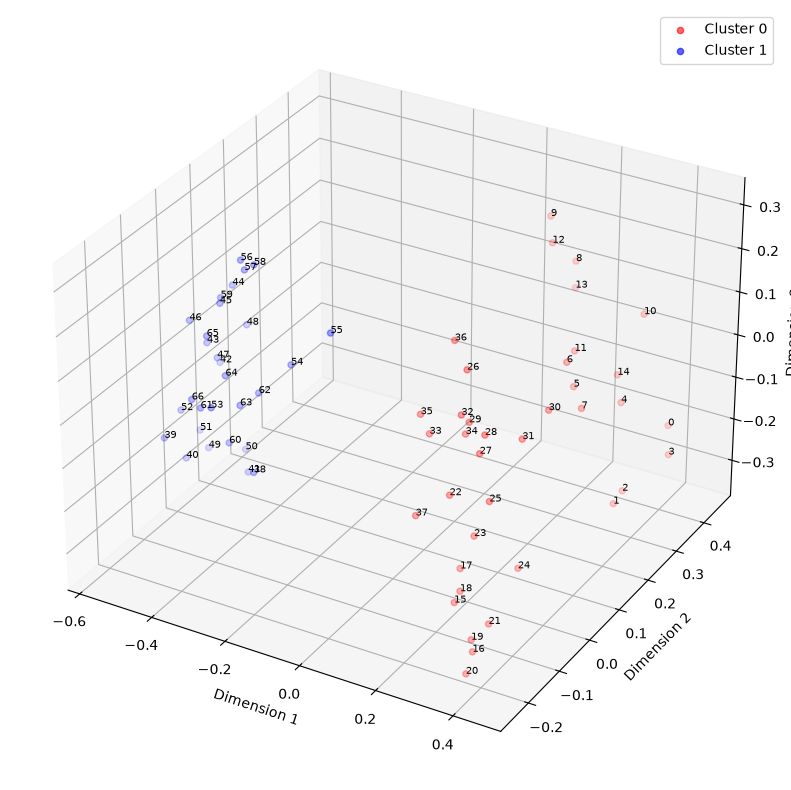

RED cluster (n=38): The common theme of these text chunks is Gaurav Kamath's professional profile, highlighting his extensive expertise in software architecture, particularly in backend engineering and automotive telematics, along with his academic background in computer science, interests in AI and data science, and active involvement in community service and coordination.

BLUE cluster (n=29): The common theme in these text chunks is a personal reflection on the joys and experiences of hiking as a way to connect with nature, enhance physical fitness, and foster meaningful social interactions, contrasting with a technology-heavy professional life. The author shares their evolving appreciation for hiking, including the preparation and pacing involved, while highlighting the diverse environments and landscapes that each trail offers.



In [12]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (enables 3D projection)
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# 1. get embeddings
response = client.embeddings.create(
    model="text-embedding-3-small",
    input=chunks
)
embeddings = np.array([item.embedding for item in response.data])

# 2. cluster in original high-dim space
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(embeddings)

# 3. reduce to 3D for plotting
xyz = PCA(n_components=3).fit_transform(embeddings)

# 4. plot, colored by cluster, with legend
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

for cluster_id, color, name in [(0, 'red', 'Cluster 0'), (1, 'blue', 'Cluster 1')]:
    mask = cluster_labels == cluster_id
    ax.scatter(xyz[mask, 0], xyz[mask, 1], xyz[mask, 2], c=color, alpha=0.6, label=name)

for i, (x, y, z) in enumerate(xyz):
    ax.text(x, y, z, str(i), fontsize=7)

ax.set_xlabel("Dimension 1")
ax.set_ylabel("Dimension 2")
ax.set_zlabel("Dimension 3")
ax.legend()
plt.tight_layout()
plt.show()

# 5. describe each cluster using an LLM
for cluster_id in [0, 1]:
    cluster_chunks = [c for c, l in zip(chunks, cluster_labels) if l == cluster_id]
    sample_text = "\n---\n".join(cluster_chunks[:10])

    resp = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{
            "role": "user",
            "content": f"These text chunks belong to the same cluster. In 1-2 sentences, describe the common theme:\n\n{sample_text}"
        }]
    )
    color = "RED" if cluster_id == 0 else "BLUE"
    print(f"{color} cluster (n={len(cluster_chunks)}): {resp.choices[0].message.content}\n")

In [13]:
import chromadb

# Intialize the Chroma DB
chroma_client = chromadb.PersistentClient(path= "./chroma_db_twin")

#intialize ChromaDB Client (In Memory Storage)
# chroma_client = chromadb.client()

collection = chroma_client.get_or_create_collection(name="digital-twin")

# Empty the collection before adding the new data.
if collection.get()["ids"]:
    collection.delete(collection.get()["ids"]) 

print(collection.get())

{'ids': [], 'embeddings': None, 'documents': [], 'uris': None, 'included': ['metadatas', 'documents'], 'data': None, 'metadatas': []}


In [14]:
#prepare the data for storage

# ids = [f"chunk_{i}" for i in range(len(chunks))]
# metadatas = [{"source": "netflix_culture_pdf", "chunk_index":i} for i in range(len(chunks))]
#print(embeddings)
collection.add(
    ids=ids,
    embeddings=embeddings,
    documents=chunks,
    metadatas=metadatas
)

pprint(collection.get(include=["metadatas", "documents", "embeddings"]))

{'data': None,
 'documents': [' Gaurav Kamath is a Software Architect with strong experience '
               'in backend engineering,\n'
               'Java/J2EE, Spring, Spring Boot, microservices, APIs, '
               'distributed systems, and enterprise\n'
               'application development. He has worked deeply in the '
               'automotive telematics domain,\n'
               'building and supporting systems where backend services '
               'communicate with vehicles,\n'
               'mobile apps, web portals, databases, messaging systems, and '
               'cloud/infrastructure components.\n'
               '\n',
               'ng systems, and cloud/infrastructure components.\n'
               '\n'
               'He currently works in areas connected to automotive '
               'telematics, vehicle APIs, vehicle\n'
               'status, vehicle location, odometer data, provisioning, '
               'ignition events, data processors,\n'
         

In [15]:
#Generate embedding for a test query
test_query = "school"

# 1. get embeddings
response = client.embeddings.create(
    model="text-embedding-3-small",
    input=test_query
)

#print(response.data)
embeddings = np.array([item.embedding for item in response.data])

#print(embeddings[0])

#collection.query()

results = collection.query(
    query_embeddings=embeddings,
    n_results=3,
    include=["documents", "metadatas", "embeddings"]
)

#print(results["metadatas"] )

print(f"Search Query: {test_query}\n")
print("Retrieved Chunks \n")
for a, b in zip(results["documents"][0], results["metadatas"][0]):
    #print(f"Chunk{b['chunk_index']}: \n{a}\n ")
    print(f"Document {b["source"]} Chunk{b['chunk_index']}: \n{a}\n ")


Search Query: school

Retrieved Chunks 

Document Gaurav General Info Chunk13: 
sages, he prefers polished but natural language.

Additional Info:
- In 2001, gaurav joined the high school.
- Gaurav enjoys cooking and experimenting with new recipes in his free time.
- Gaurav loves to travel and explore new cultures and cuisines.
- Gaurav is an avid sports enthusiast, particularly interested in cricket and pickleball. He enjoys playing and watching these sports.,

 
Document Gaurav's Education Chunk1: 
re, data platforms, and artificial intelligence.

I completed my formal education in a technical discipline related to computer science and engineering. During my academic years, I studied subjects such as programming, data structures, algorithms, database management systems, computer networks, operating systems, software engineering, and object-oriented design. These subjects gave me a strong foundation in both theoretical concepts and practical application development.


 
Document Gaura

In [16]:
tools = []

In [17]:
pushover_user= os.getenv("PUSHOVER_USER")
pushover_token = os.getenv("PUSHOVER_TOKEN")
pushover_url = "https://api.pushover.net/1/messages.json"

print(f"PUSHOVER_USER: {pushover_user}")
print(f"PUSHOVER_TOKEN: {pushover_token}")

# Pushover API
def send_notification(message: str):
    payload = {
        "user": pushover_user,
        "token": pushover_token,
        "message": message
    }
    requests.post(pushover_url, data=payload)


send_notification_function = {
    "name": "send_notification",
    "description": "Send a push notifcation to the real-world version of you via pushover on phone. use this if the user need to alert the real-world version of you.",
    "parameters": {
        "type": "object",
        "properties": {
            "message": {
                "type": "string",
                "description": "The notifiication message to send to the user device"
            }
        },
        "required": ["message"]
    }
}

tools.append({
    "type": "function",
    "function": send_notification_function
})


PUSHOVER_USER: usirayudtxm7k5nn6jj39qczvaqibj
PUSHOVER_TOKEN: a7macpjd2i18up2bmekhwf53p94ewm


In [18]:
import random

# Simulate a rolling a single six-sided die.
def dice_roll():
    result = random.randint(1,6)
    return result

# Describe the function for the LLM to yse
roll_dice_function = {
    "name": "dice_roll",
    "description": "Simiulate rolling a single six-sided die and return the result. use this when user wants to roll a die or when you want to generate a random number between 1 and 6.",
    "parameters": {
        "type": "object",
        "properties": {},
        "required": []
    }
}

# Add the function to the tools list
tools.append({
    "type": "function",
    "function": roll_dice_function
})

In [19]:
def handle_tool_call(tool_calls):
    tool_results = []

    for tool_call in tool_calls:
        function_name = tool_call.function.name
        args = json.loads(tool_call.function.arguments)
        # print(f"Calling funtion: {function_name}")

        # Route the tool call to the appropropriate function based on the function name
        if function_name == "send_notification":
        # Actually send the notification using the tool
            send_notification(args["message"])
            content =  f"Notification sent: {args['message']}"
            #print(f" Sent notification: {args['message']}")
        elif function_name == "dice_roll":
            # Call the second function here
            result = dice_roll()
            content = f"Dice rolled: {result}"
        else:
            content = f"Unknown function: {function_name}"

        tool_call_result = {
            "role": "tool",
            "content": content,
            "tool_call_id": tool_call.id 
        }
        #print(f"Tool call result: {tool_call_result}")
        tool_results.append(tool_call_result)
    
    # return what to add to our "context" (about tool call results), a dictionary.
    return tool_results

In [20]:
from email import message
from urllib import response


def respond_to_ai(message, history):

    # RAG
    # 1. get embeddings
    response = client.embeddings.create(
        model="text-embedding-3-small",
        input=[message]
    )

    #embeddings = np.array([item.embedding for item in response.data])
    embeddings = response.data[0].embedding

    results = collection.query(
        query_embeddings=embeddings,
        #n_results=3,
        #include=["documents", "metadatas", "embeddings"]
    )

    #stitch retrieved Chunks together to create the context for the response
    context = "\n---\n".join(results["documents"][0])
    print("Retrieved Chunks \n")
    for a, b in zip(results["documents"][0], results["metadatas"][0]):
        print(f"Document {b["source"]} Chunk{b['chunk_index']}: \n{a}\n ")
    
    system_message_enhanced = system_message + "\n\n Context:\n" + context
    

    # As usual
    messages = [{"role": "system", "content": system_message_enhanced}] + history + [{"role": "user", "content": message}]  
    print("Messages sent to the model: \n" + system_message_enhanced  )  # Debugging line to see the messages being sent to the model
    #client = OpenAI(api_key=OPENAI_API_KEY)
    response = client.chat.completions.create(
        model= "gpt-4.1-mini",
        messages=messages,
        tools=tools
    )

    # Check if model wants to call a tool
    message = response.choices[0].message

    while message.tool_calls:
        pprint(message.tool_calls)
        # Handle tool call
        tool_result = handle_tool_call(message.tool_calls)
        # add message to "context"
        messages.append(message)
        # Add info about the tool call response to the "context", i.e. messages.
        messages.extend(tool_result)

        response = client.chat.completions.create(
            model= "gpt-4.1-mini",
            messages=messages,
            tools=tools
        )
        message = response.choices[0].message
        # may be consider adding a protection from infinite loops.
        
    return(message.content)


    # reply = response.choices[0].message.content
    # return reply

In [21]:
gr.ChatInterface(fn=respond_to_ai).launch(inbrowser=True)

* Running on local URL:  http://127.0.0.1:7863
* To create a public link, set `share=True` in `launch()`.


/Users/gauravkamath/Documents/Code/ai-engineering/ai_env/lib/python3.14/site-packages/gradio/routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)


Retrieved Chunks 

Document Gaurav General Info Chunk12: 
it works, and how to apply it in
a real project.

Communication style:
Direct, friendly, respectful, practical, and slightly warm. He often asks for messages to
be rephrased in a polite, natural, and human way. He prefers communication that is clear
and not overly formal. For WhatsApp messages, he likes short, friendly, and effective wording.
For professional messages, he prefers polished but natural language.


 
Document Gaurav General Info Chunk9: 
ess challenges, and WhatsApp group coordination.

He often helps bring people together, create polls, coordinate schedules, communicate
updates, motivate participation, and make group activities smoother for others. He values
people's time, clear communication, fairness, inclusion, and practical coordination.


 
Document Gaurav's Hiking expedition Chunk25: 
necting from screens and spending time outdoors.

For my Digital Twin, hiking should be represented as more than a simple hob

/Users/gauravkamath/Documents/Code/ai-engineering/ai_env/lib/python3.14/site-packages/gradio/routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)
/Users/gauravkamath/Documents/Code/ai-engineering/ai_env/lib/python3.14/site-packages/gradio/routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)


Retrieved Chunks 

Document Gaurav's Hiking expedition Chunk0: 

## My Interest in Hiking and the Outdoors

Hiking is one of my favorite outdoor activities because it gives me an opportunity to step away from technology, spend time in nature, and challenge myself physically. Most of my professional and learning activities involve computers, software systems, architecture discussions, coding, and problem-solving. Hiking provides a completely different environment where I can slow down, observe my surroundings, and clear my mind.


 
Document Gaurav's Hiking expedition Chunk23: 
le improving my fitness and outdoor preparation.

I would also like to combine hiking with travel. Visiting a new city or region becomes more memorable when the trip includes a trail, scenic walk, or outdoor experience. Hiking provides a different perspective of a destination compared with seeing it only from a car or visiting popular tourist locations.


 
Document Gaurav's Hiking expedition Chunk14: 
he weather

/Users/gauravkamath/Documents/Code/ai-engineering/ai_env/lib/python3.14/site-packages/gradio/routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)
